In [1]:
import numpy as np
from itertools import batched

In [2]:
from transformers import CLIPModel, CLIPProcessor
from torchvision.utils import make_grid
from torchvision.io import read_image
from torchvision import transforms
from pathlib import Path
import torch

In [3]:
images = []
# Load image paths from the primary directory
images.extend(Path("/content/drive/MyDrive/images_with_product_ids").glob("*.jpg"))
# Load image paths from the secondary directory
images.extend(Path("/content/drive/MyDrive/images_with_product_ids1").glob("*.jpg"))

In [4]:
def get_text_embedding(text):
  # Initialize CLIP model and processor
  clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
  clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

  # Tokenize and prepare text input
  inputs = clip_processor(text=[text], return_tensors="pt", padding=True)

  # Extract text features using the model
  text_features = clip_model.get_text_features(**inputs)

  return text_features

def load_transform_images(image_paths):
  # Define target dimensions
  target_size = (240, 240)
  # Transformation to resize and ensure 3-channel RGB
  reshape_transform = lambda image_tensor: transforms.Resize(target_size)(image_tensor).expand(3, -1, -1)
  # Load and process each image from the path list
  images = [reshape_transform(read_image(image)) for image in image_paths]
  return images

def get_image_embeddings(image_paths):
  # Initialize CLIP components
  clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
  clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

  # Load and preprocess images for the model
  images = load_transform_images(image_paths)
  inputs = clip_processor(images=images, return_tensors="pt")
  # Extract numerical image embeddings
  image_embeddings = clip_model.get_image_features(**inputs)
  return image_embeddings

In [5]:
batch_size = 32
total_batches = int(np.ceil(len(images)/ batch_size))

i = 0
embedding_files = []
for image_fps in batched(images, batch_size):
  i += 1
  print(f"Processing batch {i}/{total_batches}")
  file_name = f"/content/1/batch_{i}.pt"
  torch.save(get_image_embeddings(image_fps), file_name)
  embedding_files.append(file_name)

Processing batch 1/74


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processing batch 74/74


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [67]:
embedding_files

['/content/1/batch_1.pt',
 '/content/1/batch_2.pt',
 '/content/1/batch_3.pt',
 '/content/1/batch_4.pt',
 '/content/1/batch_5.pt',
 '/content/1/batch_6.pt',
 '/content/1/batch_7.pt',
 '/content/1/batch_8.pt',
 '/content/1/batch_9.pt',
 '/content/1/batch_10.pt',
 '/content/1/batch_11.pt',
 '/content/1/batch_12.pt',
 '/content/1/batch_13.pt',
 '/content/1/batch_14.pt',
 '/content/1/batch_15.pt',
 '/content/1/batch_16.pt',
 '/content/1/batch_17.pt',
 '/content/1/batch_18.pt',
 '/content/1/batch_19.pt',
 '/content/1/batch_20.pt',
 '/content/1/batch_21.pt',
 '/content/1/batch_22.pt',
 '/content/1/batch_23.pt',
 '/content/1/batch_24.pt',
 '/content/1/batch_25.pt',
 '/content/1/batch_26.pt',
 '/content/1/batch_27.pt',
 '/content/1/batch_28.pt',
 '/content/1/batch_29.pt',
 '/content/1/batch_30.pt',
 '/content/1/batch_31.pt',
 '/content/1/batch_32.pt',
 '/content/1/batch_33.pt',
 '/content/1/batch_34.pt',
 '/content/1/batch_35.pt',
 '/content/1/batch_36.pt',
 '/content/1/batch_37.pt',
 '/content

In [7]:
# Concatenate all batch tensors into a single master embedding tensor
# Extract the pooler_output from each saved batch file
image_embeddings = torch.cat([
    torch.load(fp, weights_only=False).pooler_output for fp in embedding_files
])

In [8]:
image_embeddings.shape

torch.Size([2349, 512])

In [10]:
sum(image_embedding.element_size() for image_embedding in image_embeddings) / 1e3

9.396

In [16]:
from huggingface_hub.utils import tqdm
def rank_items(text_embedding: torch.Tensor, image_embeddings: torch.Tensor):
    scores = []
    # Using the functional version is often cleaner for single comparisons
    cosine_similarity = torch.nn.CosineSimilarity(dim=1)

    # Ensure text_embedding is 2D [1, 512] for the similarity function
    if text_embedding.dim() == 1:
        text_embedding = text_embedding.unsqueeze(0)

    # Renamed loop variable to 'img_emb' to avoid overwriting the 'image_embeddings' tensor
    for img_emb in tqdm(image_embeddings):
        # img_emb is [512], we unsqueeze it to [1, 512]
        score = cosine_similarity(text_embedding, img_emb.unsqueeze(0))

        # .item() or float() both work now that the shape is a single scalar!
        scores.append(score.item())

    return scores

In [37]:
text_embedding = get_text_embedding("purse")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [40]:
scores = rank_items(text_embedding.pooler_output, image_embeddings)

In [41]:
np.argsort(scores)

array([1789, 1798,  876, ..., 2253,  411, 1444])

In [42]:
idx = np.argsort(scores)
np.array(scores)[idx][::-1]

array([0.23639108, 0.23639108, 0.23368059, ..., 0.1409355 , 0.13857466,
       0.13685408])

In [48]:
idx = np.argsort(scores)
np.array(scores)[idx][::-1]

array([0.23639108, 0.23639108, 0.23368059, ..., 0.1409355 , 0.13857466,
       0.13685408])

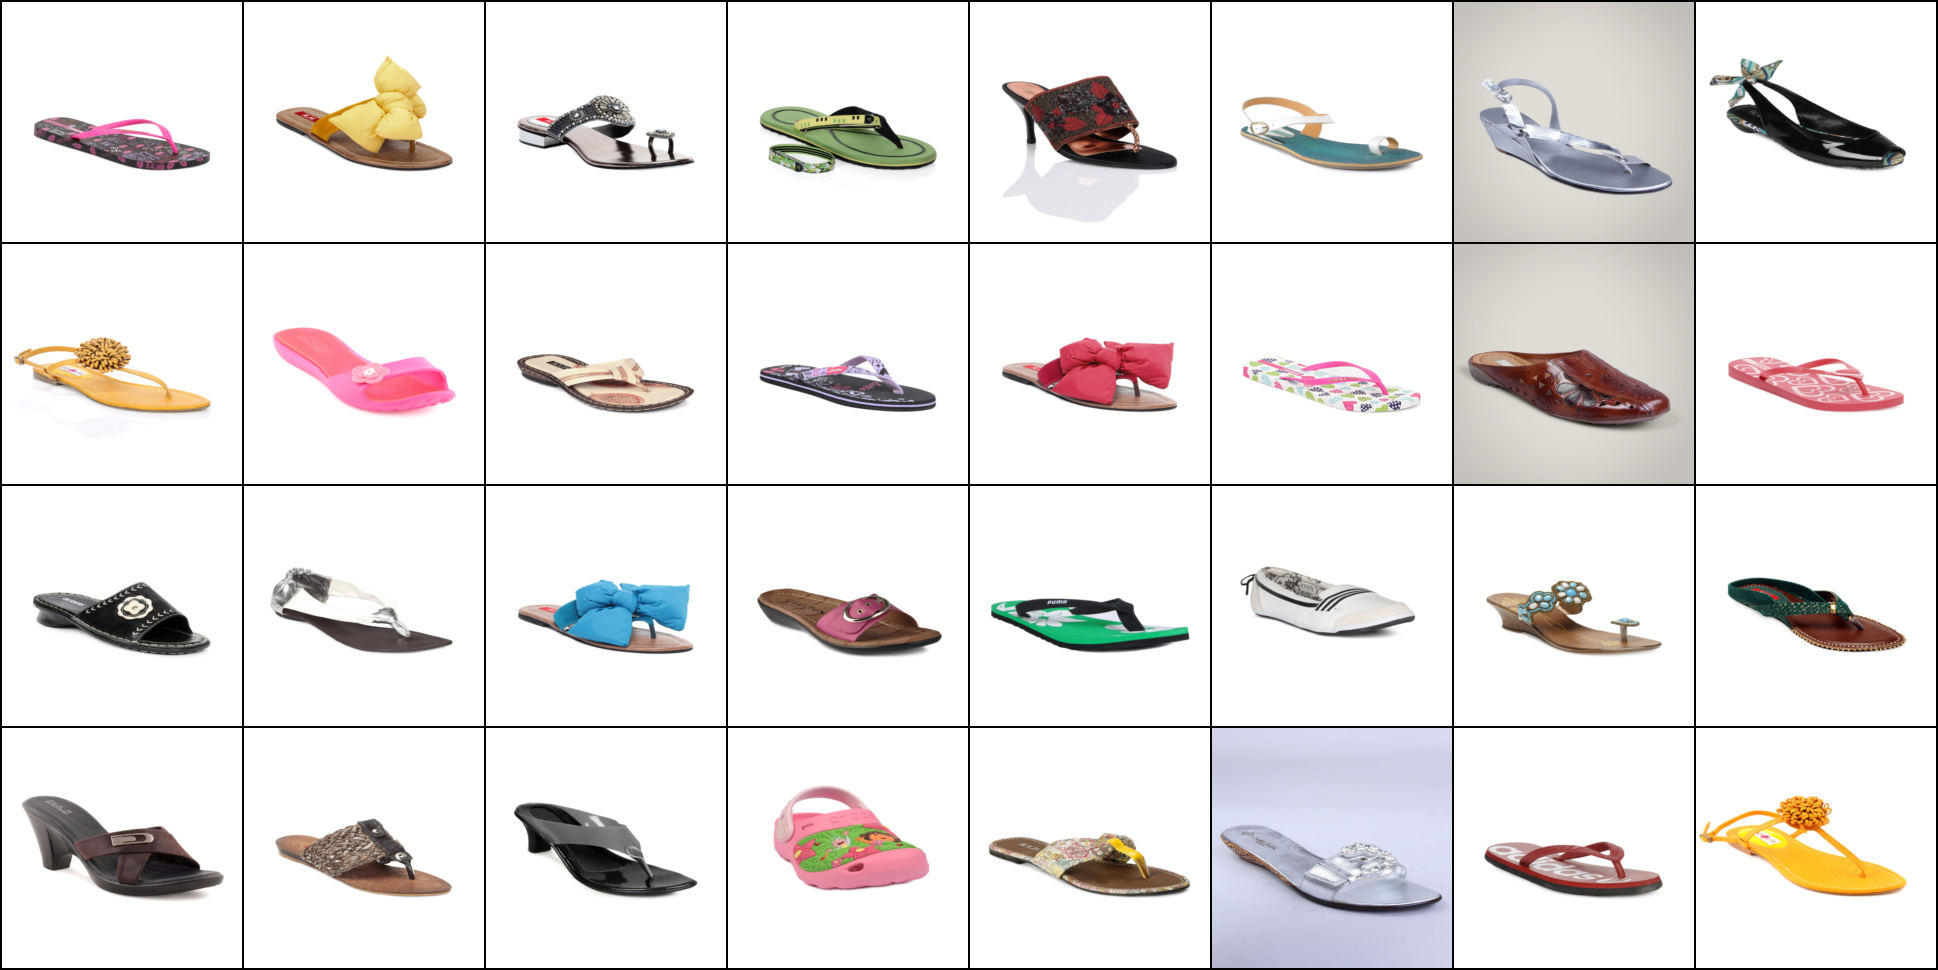

In [50]:
target_size = (240, 240)
num_images = 32
resize_transform = transforms.Resize(target_size)

# Sort scores high-to-low
idx = np.argsort(scores)                  # already defined
idx = idx[::-1]                           # reverse for highest first

# Clip idx to avoid out-of-bounds
idx = idx[idx < len(images)]

# Select top images
top_images = np.array(images)[idx][:num_images]

# Read, resize, and expand to 3 channels
resized_images = [resize_transform(read_image(str(img))).expand(3, -1, -1) for img in top_images]

# Make grid and display
grid = make_grid(resized_images)
display(transforms.ToPILImage()(grid))

In [46]:
import torch.nn.functional as F

def rank_items(text_embedding, image_embeddings):
  # Normalize vectors to ensure cosine similarity is calculated correctly
  text_embedding_norm = F.normalize(text_embedding, p=2, dim=1)
  image_embeddings_norm = F.normalize(image_embeddings, p=2, dim=1)

  # Calculate similarity scores via matrix multiplication
  scores = (image_embeddings_norm @ text_embedding_norm.T).squeeze()
  return scores.tolist()

In [60]:
def generate_product_feed(query, images, image_embeddings, num_images=32):
    scores = rank_items(get_text_embedding(query).pooler_output, image_embeddings)

    sort_idx = np.argsort(scores)[::-1]
    sort_idx = sort_idx[sort_idx < len(images)]
    ranked_images = np.array(images)[sort_idx][:num_images]

    target_size = (240, 240)
    reshape_transform = lambda image_tensor: transforms.Resize(target_size)(image_tensor).expand(3, -1, -1)
    resized_images = [reshape_transform(read_image(image)) for image in ranked_images]
    grid = make_grid(resized_images)
    display(transforms.ToPILImage()(grid))

    return ranked_images

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


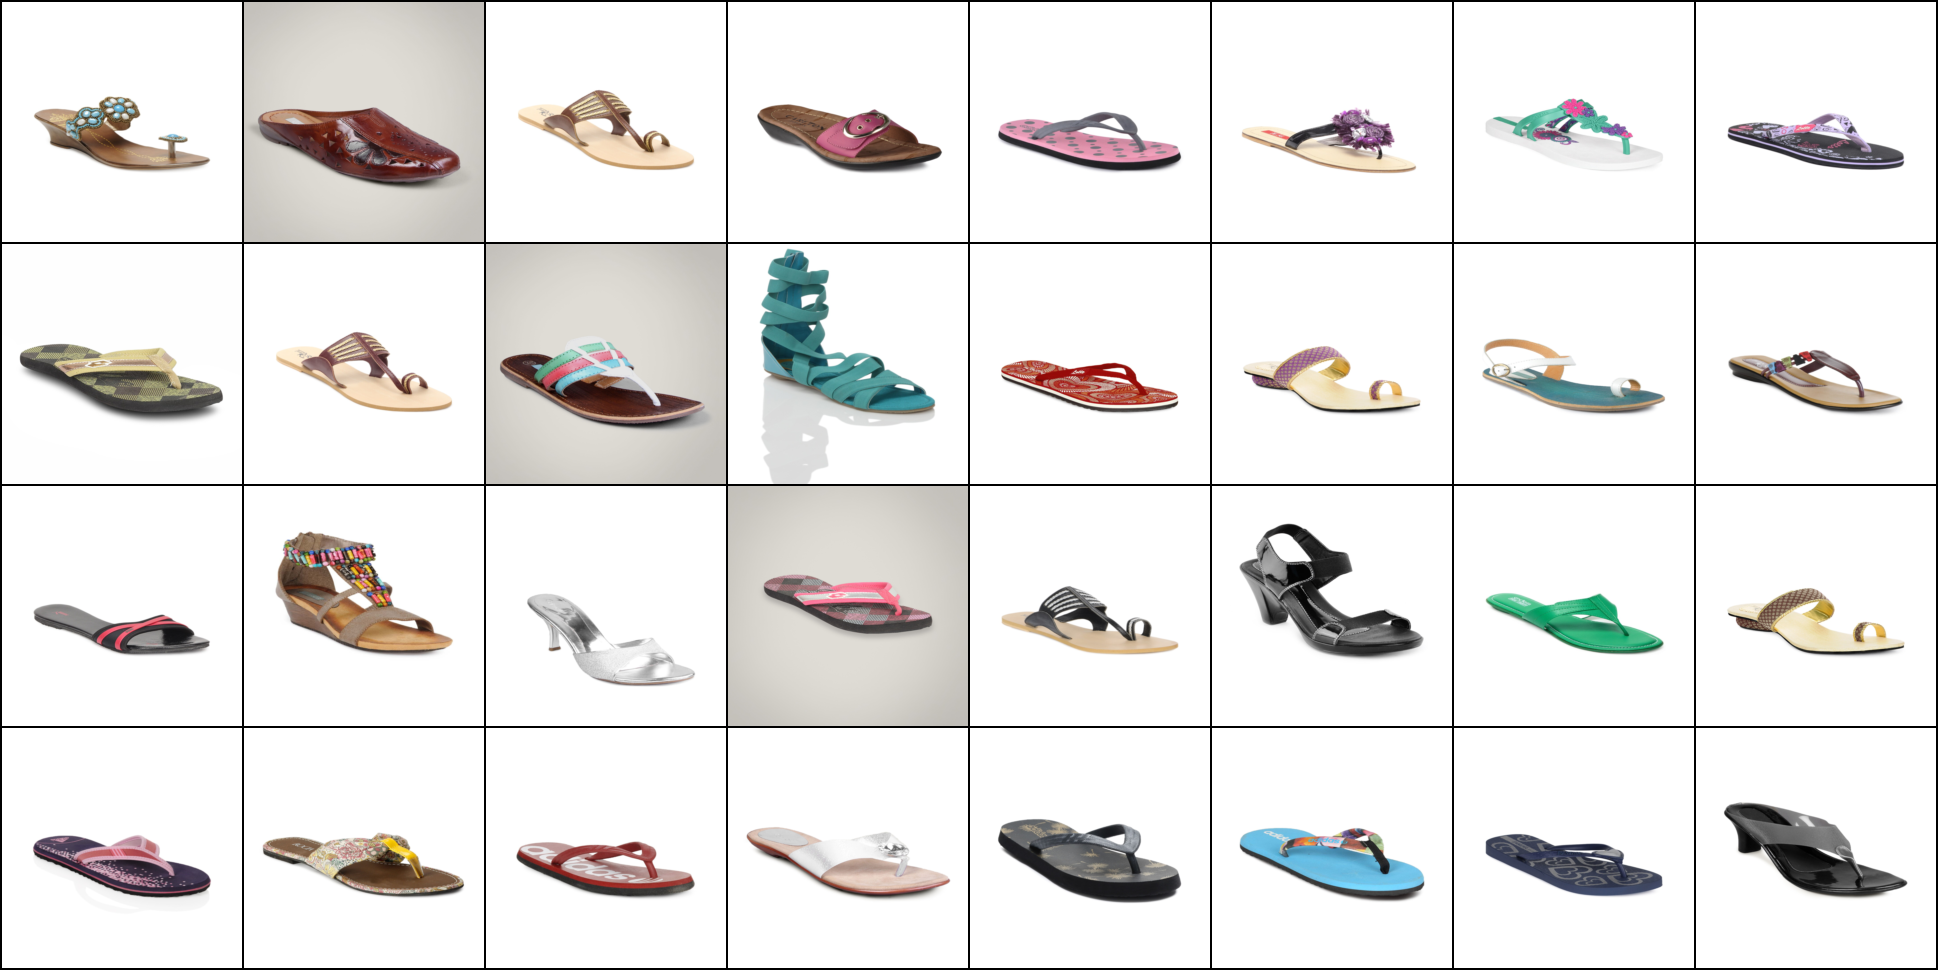

array(['/content/images/53139.jpg', '/content/images/2889.jpg',
       '/content/images/47537.jpg', '/content/images/13554.jpg',
       '/content/images/24633.jpg', '/content/images/56933.jpg',
       '/content/images/44205.jpg', '/content/images/58327.jpg',
       '/content/images/6449.jpg', '/content/images/47538.jpg',
       '/content/images/2872.jpg', '/content/images/33106.jpg',
       '/content/images/44722.jpg', '/content/images/47531.jpg',
       '/content/images/14378.jpg', '/content/images/47624.jpg',
       '/content/images/43411.jpg', '/content/images/41715.jpg',
       '/content/images/2900.jpg', '/content/images/6447.jpg',
       '/content/images/47536.jpg', '/content/images/27075.jpg',
       '/content/images/45796.jpg', '/content/images/47530.jpg',
       '/content/images/34516.jpg', '/content/images/17018.jpg',
       '/content/images/53445.jpg', '/content/images/3134.jpg',
       '/content/images/20940.jpg', '/content/images/6169.jpg',
       '/content/images/49831.jp

In [66]:
generate_product_feed("unique", images, image_embeddings)